# 1. Data Cleaning - 타이타닉 데이터 다루기

타이타닉 데이터셋을 활용해 데이터 정제의 전반적인 과정을 실습해보았다.

**구성 내용**
- 데이터 로드 및 탐색
- 불필요한 컬럼 삭제, 결측치 처리
- 이상치 탐지 및 처리
- 중복 데이터 처리 및 데이터 변환
- 텍스트 데이터 처리
- 날짜/시간 데이터 처리

## 1-1. 파이썬으로 데이터 둘러보기

Pandas 라이브러리를 Import하고 타이타닉 데이터를 업로드한다.

- `pd.read_csv()` : 파일을 DataFrame 혹은 Series로 읽어오는 함수
- 경로는 절대경로 또는 상대경로 모두 가능

In [87]:
import pandas as pd 

# read_csv 함수로 경로에 위치한 파일 불러오기
data = pd.read_csv("/Users/chankyulee/Desktop/ModuLABS/02_DataPreprocessing/titanic.csv")

# 결과 출력
data

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...,...
880,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0,1912-01-29
881,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1,1912-03-30
882,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1,1912-03-01


### 데이터 미리보기

- `.head(n)` : 데이터의 앞 행 $n$개만 출력 (기본값 5)
- `.tail(n)` : 데이터의 뒤 행 $n$개만 출력 (기본값 5)
- 데이터가 클 때 전체를 출력하면 화면이 지저분해지므로, head/tail로 간단히 확인!

In [88]:
# 숫자를 안쓰면 기본값은 5개만 출력한다.
data.head() 

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03


In [89]:
data.tail()

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
880,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0,1912-01-29
881,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1,1912-03-30
882,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1,1912-03-01
884,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,Q,0,1912-03-05


### 데이터 정보 확인

- `.info()` : 데이터의 인덱스, 컬럼, Null이 아닌 값 개수, 데이터 타입, 메모리 사용량을 볼 수 있다.
  - Non-Null Count를 보면 결측치가 있는 열을 바로 파악할 수 있다
- `.describe()` : 데이터의 통계 요약표. 숫자형 데이터에 대해 개수, 평균, 표준편차, 최소/최대, 4분위값(25%, 50%, 75%, max)을 볼 수 있다.
  - 여기서 이상치(outlier)를 발견할 수 있다 (예: Age max가 145)

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       885 non-null    int64  
 1   Name         885 non-null    object 
 2   Gendr        885 non-null    object 
 3   Age          879 non-null    float64
 4   SibSp        885 non-null    int64  
 5   Parch        885 non-null    int64  
 6   Ticket       885 non-null    object 
 7   Embarked     883 non-null    object 
 8   Survived     885 non-null    int64  
 9   ticket_date  885 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 69.3+ KB


In [91]:
data.describe()

,Pclass,Age,SibSp,Parch,Survived
count,885.000000,879.000000,885.000000,885.000000,885.000000
mean,2.311864,29.679181,0.525424,0.377401,0.377401
std,0.836069,13.559664,1.109746,0.805768,0.485011
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,0.000000
75%,3.000000,35.000000,1.000000,0.000000,1.000000
max,3.000000,145.000000,8.000000,6.000000,1.000000


### Series와 DataFrame

Pandas의 핵심 자료구조 두 가지:

- **Series** = 1열짜리 리스트 (인덱스 + 값) → 1차원
- **DataFrame** = 여러 열의 표 (인덱스 + 열이름 + 값) → 2차원

**선택 방법에 따라 반환 타입이 달라진다:**
- 대괄호 1개 `data['열']` → **Series** 반환
- 대괄호 2개 `data[['열']]` → **DataFrame** 반환 (리스트 안에 리스트 = 2차원 = DataFrame)

In [92]:
# Series
data['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
880                                Montvila, Rev. Juozas
881                         Graham, Miss. Margaret Edith
882             Johnston, Miss. Catherine Helen "Carrie"
883                                Behr, Mr. Karl Howell
884                                  Dooley, Mr. Patrick
Name: Name, Length: 885, dtype: object

- `pd.DataFrame()` : Series 객체를 DataFrame으로 변환할 수 있다.

In [93]:
# DataFrame
# 리스트 안에 리스트로 넣어주면 2차원 배열이 되므로 DataFrame 생성
data[['Name']]

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
880,"Montvila, Rev. Juozas"
881,"Graham, Miss. Margaret Edith"
882,"Johnston, Miss. Catherine Helen ""Carrie"""
883,"Behr, Mr. Karl Howell"


## 1-2. 불필요한 컬럼 삭제, 누락된 결측치 처리

### 중복 데이터 확인

- `data.duplicated()` : Boolean Series 생성
  - 모든 열의 값이 이전 행과 완전히 동일하면 `True`, 아니면 `False` 반환
- 이것을 `data[]`로 감싸면 **불리언 인덱싱** → True에 해당하는 행(중복된 데이터)만 확인할 수 있다
- `data[]` 안에 조건문을 넣어 필터링이 가능하다

> **불리언 인덱싱 원리:** 조건식이 True/False Series를 만들고, 대괄호 안에 넣으면 True인 행만 필터링된다

In [94]:
data[data.duplicated()]

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
25,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,S,0,1912-03-14
632,3,"Skoog, Miss. Mabel",female,9.0,3,2,347088,S,0,1912-03-16
714,1,"Endres, Miss. Caroline Louise",female,38.0,0,0,PC 17757,C,1,1912-03-14


In [95]:
# 특정 이름 행 찾기
data[data['Name'] == 'Palsson, Miss. Torborg Danira']

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
24,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,S,0,1912-03-14
25,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,S,0,1912-03-14


### 중복 데이터 제거

- `drop_duplicates()` : 중복된 데이터 행을 제거한다
  - 기본적으로 첫 번째 행을 유지하고 나머지 중복 행을 삭제
  - `keep='last'`로 마지막 행을 유지할 수도 있다

In [96]:
data = data.drop_duplicates()

### 불필요한 컬럼/행 삭제

- `drop(대상, axis, inplace)` : 컬럼 또는 행 삭제
  - `axis=0` (기본값) → **행** 삭제
  - `axis=1` → **열** 삭제
  - `inplace=True` → 원본 데이터를 직접 수정 (반환값 None)
  - `inplace=False` (기본값) → 원본은 그대로, 새 DataFrame 반환

> **주의:** `inplace=True`를 쓰면 `result = data.drop(..., inplace=True)` 했을 때 result가 None이 된다

In [97]:
data.drop('Name', axis=1, inplace=True)

/var/folders/92/1z5rtryn4tdg88w4gm0bv9yw0000gn/T/ipykernel_29973/1549323352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop('Name', axis=1, inplace=True)


In [98]:
data.head()

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03


In [99]:
# axis=0으로 특정 행 삭제 (인덱스 번호 기준)
data.drop(2, axis=0)

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [100]:
# 여러 컬럼 동시 삭제 (리스트로 전달)
data.drop(['Pclass','Age'], axis=1)

,Gendr,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,male,1,0,A/5 21171,S,0,1912-01-12
1,female,1,0,PC 17599,C,1,1912-03-29
2,female,0,0,STON/O2. 3101282,S,1,1912-02-23
3,female,1,0,113803,S,1,1912-03-28
4,male,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...
880,male,0,0,211536,S,0,1912-01-29
881,female,0,0,112053,S,1,1912-03-30
882,female,1,2,W./C. 6607,S,0,1912-04-07
883,male,0,0,111369,C,1,1912-03-01


### loc vs iloc 인덱싱

| 메서드 | 기준 | 슬라이싱 끝값 | 예시 |
|--------|------|-------------|------|
| `loc[]` | **라벨(이름)** 기반 | 포함 | `loc['a':'c']` → a, b, c 모두 포함 |
| `iloc[]` | **정수위치(0부터)** 기반 | 미포함 | `iloc[0:3]` → 0, 1, 2만 포함 |

- 현재 데이터는 인덱스 라벨이 숫자이므로 loc/iloc 결과가 동일하게 보인다
- 인덱스를 문자열로 변경하면 차이가 명확해진다

In [101]:
data.loc[[4,5,6]]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
6,1,male,54.0,0,0,17463,S,0,1912-03-14


In [102]:
data.iloc[[4,5,6]]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
6,1,male,54.0,0,0,17463,S,0,1912-03-14


### 데이터 복사 및 인덱스 라벨링

- `.copy()` : 데이터 복사 → 기본적으로 **깊은 복사**(deep copy)
  - 깊은 복사: 원본과 완전히 독립적인 복사본 생성. 복사본을 수정해도 원본에 영향 없음
  - 얕은 복사(`copy(deep=False)`): 원본과 메모리를 공유. 복사본 수정 시 원본도 바뀔 수 있음
- `.index` : 인덱스 라벨을 직접 지정할 수 있다

In [103]:
temp = data.head().copy()
temp

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03


In [104]:
temp.index = ['a', 'b', 'c', 'd', 'e']
temp

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
a,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
b,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
c,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
d,1,female,NaN,1,0,113803,S,1,1912-03-28
e,3,male,35.0,0,0,373450,S,0,1912-04-03


인덱스를 문자열로 바꾼 후 loc/iloc의 차이를 확인:

- `loc['c']` : loc은 라벨 기반이므로 문자열 'c'로 접근
- `iloc[2]` : iloc은 위치 기반이므로 정수 2로 접근 (0부터 세는 세 번째)
- 둘 다 같은 행을 가리키며, **Series**로 반환된다 (행 하나를 꺼내면 Series)

In [105]:
temp.loc['c']

Pclass                        3
Gendr                    female
Age                        26.0
SibSp                         0
Parch                         0
Ticket         STON/O2. 3101282
Embarked                      S
Survived                      1
ticket_date          1912-02-23
Name: c, dtype: object

In [106]:
temp.iloc[2]

Pclass                        3
Gendr                    female
Age                        26.0
SibSp                         0
Parch                         0
Ticket         STON/O2. 3101282
Embarked                      S
Survived                      1
ticket_date          1912-02-23
Name: c, dtype: object

### 결측치(NaN) 확인 및 처리

- `.isna()` (또는 `.isnull()`) : 결측치를 True/False로 반환
- `.isna().sum()` : 각 컬럼의 결측치 개수를 파악할 수 있다
- 불리언 인덱싱과 결합하면 결측치가 있는 행만 뽑아볼 수 있다

In [107]:
data.isna().sum()

Pclass         0
Gendr          0
Age            6
SibSp          0
Parch          0
Ticket         0
Embarked       2
Survived       0
ticket_date    0
dtype: int64

In [108]:
# Age 컬럼의 결측치를 데이터프레임으로 확인
data[data['Age'].isna()]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
3,1,female,NaN,1,0,113803,S,1,1912-03-28
106,3,male,NaN,0,0,312991,S,1,1912-01-27
156,3,male,NaN,0,0,SOTON/OQ 392090,S,0,1912-04-01
185,3,female,NaN,1,0,370365,Q,1,1912-03-25
213,3,male,NaN,1,0,367229,Q,0,1912-02-12
241,2,male,NaN,0,0,W./C. 14263,S,0,1912-01-31


In [109]:
# Age 컬럼 결측치 행의 인덱스 번호를 리스트로 저장
age_na_index = data[data['Age'].isna()].index

# Embarked 컬럼도 역시 동일하게
embarked_na_index = data[data['Embarked'].isna()].index

In [110]:
# 인덱스 번호를 확인해보자
data.loc[embarked_na_index]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
15,2,female,55.0,0,0,248706,NaN,1,1912-03-05
322,3,male,28.0,8,2,CA. 2343,NaN,0,1912-03-26


### 결측치 삭제: dropna()

- `.dropna()` : 결측치가 있는 **모든 행**을 삭제
- `subset` 파라미터: 특정 컬럼만 기준으로 결측치 행 삭제
  - `dropna()` → 모든 열 확인 (8개 삭제: 882 → 874)
  - `dropna(subset=['Embarked'])` → Embarked만 확인 (2개만 삭제: 882 → 880)

In [111]:
data.dropna()

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [112]:
data.dropna(subset = ['Embarked']) # Embarked 결측치 2개만 삭제

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


### 결측치 채우기: fillna()

결측치를 삭제하면 데이터 손실이 발생한다. 대안으로 적절한 값으로 채워넣을 수 있다.

- **수치형 데이터** → 평균(mean) 또는 중앙값(median)으로 채우기
  - 이상치가 있을 때는 중앙값이 더 안정적
- **범주형 데이터** → 최빈값(mode)으로 채우기

In [113]:
data['Age'].mean()

np.float64(29.718036529680365)

In [114]:
data['Age'].median()

np.float64(28.0)

In [115]:
# Age 컬럼 결측치를 중앙값(28.0)으로 채우기
data['Age'] = data['Age'].fillna(data['Age'].median())

/var/folders/92/1z5rtryn4tdg88w4gm0bv9yw0000gn/T/ipykernel_29973/2131963263.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data['Age'].fillna(data['Age'].median())


- Embarked 열의 결측치에는 최빈값 넣기
- `value_counts()` : 각 값의 빈도수를 내림차순으로 출력 → 최빈값을 확인할 수 있다

In [116]:
data['Embarked'].value_counts()

Embarked
S    638
C    165
Q     77
Name: count, dtype: int64

In [117]:
# 최빈값 'S'로 채우기
data['Embarked'] = data['Embarked'].fillna('S')

/var/folders/92/1z5rtryn4tdg88w4gm0bv9yw0000gn/T/ipykernel_29973/3634000136.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Embarked'] = data['Embarked'].fillna('S')


In [118]:
data.drop('Age', axis=1)

,Pclass,Gendr,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,1,0,A/5 21171,S,0,1912-01-12
1,1,female,1,0,PC 17599,C,1,1912-03-29
2,3,female,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,1,0,113803,S,1,1912-03-28
4,3,male,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...
880,2,male,0,0,211536,S,0,1912-01-29
881,1,female,0,0,112053,S,1,1912-03-30
882,3,female,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,0,0,111369,C,1,1912-03-01


## 1-3. 이상치 탐지 및 처리

이상치(Outlier)란 다른 데이터와 비교해 비정상적으로 크거나 작은 값을 말한다.

이상치를 탐지하는 방법:
1. **정렬** : `sort_values()`로 최솟값/최댓값 확인
2. **시각화** : 히스토그램, 산점도, 박스플롯으로 분포 확인
3. **IQR 방법** : 4분위값 기반으로 이상치 범위 설정

### 정렬로 이상치 확인

- `sort_values()` : 값 기준 오름차순 정렬 (ascending=False로 내림차순)

In [119]:
data['Age'].sort_values()

379      1.0
785      1.0
171      1.0
823      1.0
182      1.0
       ...  
490     71.0
845     74.0
627     80.0
279     97.0
321    145.0
Name: Age, Length: 882, dtype: float64

In [120]:
data['SibSp'].sort_values().tail(15)

277    4
170    4
844    4
384    5
71     5
477    5
60     5
680    5
158    8
322    8
840    8
857    8
200    8
789    8
179    8
Name: SibSp, dtype: int64

### 시각화로 이상치 확인

- `displot()` : 분포 히스토그램 → 데이터가 어디에 몰려있는지 파악
- `scatterplot()` : 산점도 → 다른 값들과 동떨어진 점 확인
- `boxplot()` : 박스플롯 → IQR 기준 이상치를 자동으로 표시

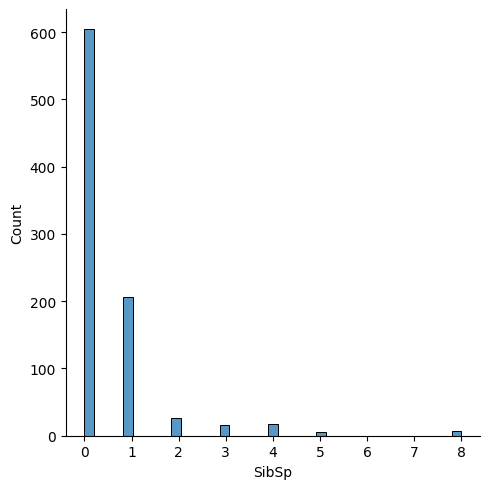

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(data['SibSp'])

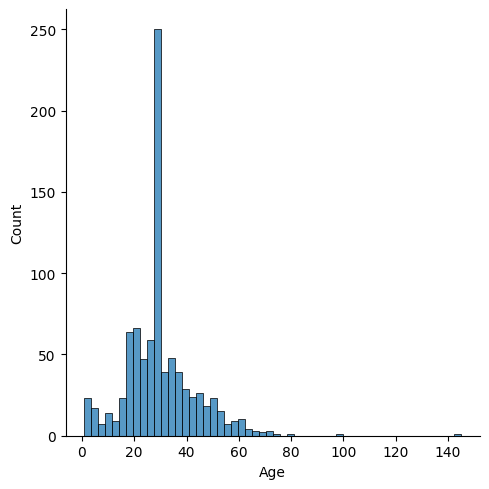

In [122]:
sns.displot(data['Age'])

<Axes: xlabel='None', ylabel='Age'>

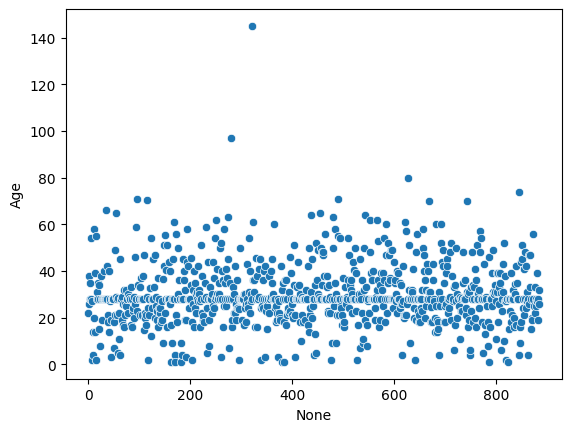

In [123]:
sns.scatterplot(x = data.index, y = data['Age'])

<Axes: xlabel='None', ylabel='SibSp'>

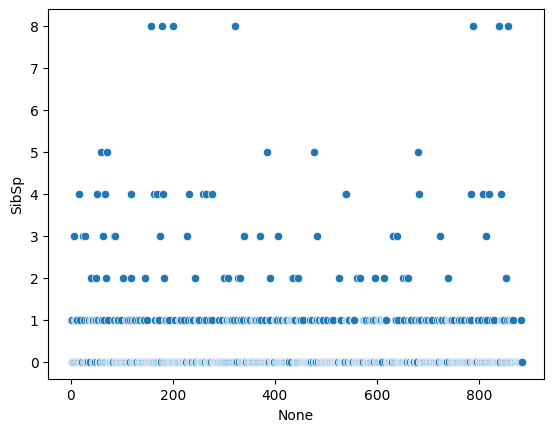

In [124]:
sns.scatterplot(x = data.index, y = data['SibSp'])

<Axes: ylabel='Age'>

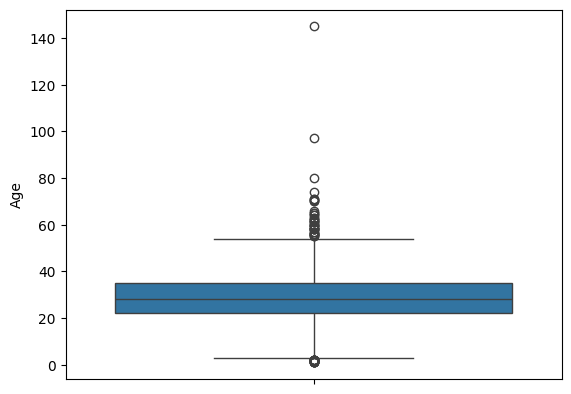

In [125]:
sns.boxplot(data['Age'])

### 이상치 처리 방법

**방법 1: 이상치 행 자체를 제거**

- IQR(Interquartile Range) = Q3(75%) - Q1(25%)
- 이상치 기준: Q1 - 1.5×IQR 미만 또는 Q3 + 1.5×IQR 초과
- 여기서는 간단히 Age > 100인 값을 제거

In [126]:
data = data[data['Age'] <= 100]

In [127]:
data['Age'].sort_values()

171     1.0
384     1.0
182     1.0
379     1.0
823     1.0
       ... 
95     71.0
490    71.0
845    74.0
627    80.0
279    97.0
Name: Age, Length: 881, dtype: float64

**방법 2: 이상치를 특정 값으로 대체 (클리핑)**

- 이상치를 삭제하지 않고, 상한/하한 값으로 대체
- `.apply()` : 데이터의 각 행에 함수를 적용
- `lambda` 함수로도 간결하게 작성 가능

In [128]:
def age_func(x):
  if x > 80:
    return 80
  else:
    return x

In [129]:
data['Age']= data['Age'].apply(age_func)

In [130]:
data['Age'].sort_values()

171     1.0
384     1.0
182     1.0
379     1.0
823     1.0
       ... 
95     71.0
490    71.0
845    74.0
627    80.0
279    80.0
Name: Age, Length: 881, dtype: float64

In [131]:
def new_age_func(x):
  if x > 70:
    return 70
  else:
    return x

### apply와 lambda

- `.apply(함수)` : 데이터에 함수 적용. 각 행(또는 열)에 함수를 하나씩 적용한다
- `lambda` : 한 줄 짜리 익명 함수. 간단한 로직일 때 def 없이 작성 가능
  - `lambda x: 반환값 if 조건 else 다른값`

In [132]:
data['Age'].apply(new_age_func)

0      22.0
1      38.0
2      26.0
3      28.0
4      35.0
       ... 
880    27.0
881    19.0
882    28.0
883    26.0
884    32.0
Name: Age, Length: 881, dtype: float64

In [133]:
# lambda로 같은 로직을 한 줄로
data['Age'].apply(lambda x: 70 if x>70 else x)

0      22.0
1      38.0
2      26.0
3      28.0
4      35.0
       ... 
880    27.0
881    19.0
882    28.0
883    26.0
884    32.0
Name: Age, Length: 881, dtype: float64

## 1-4. 중복 데이터 처리 및 데이터 형태 변환처리

### 컬럼명 변경: rename()

- `.rename(columns={기존: 신규})` 또는 `.rename({기존: 신규}, axis=1)` : 컬럼명 변경
- 인덱스도 동일하게 `.rename({기존: 신규})` 또는 `axis=0`으로 변경 가능

In [134]:
data = data.rename({'Gendr': 'Gender'}, axis = 1)
# .index 안쓰고 인덱스 번호도 변경가능
data.rename({0: 'a', 1: 'b', 2: 'c'})

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
a,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
b,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
c,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,28.0,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


### 값 변경: replace()

- `.replace({기존값: 새값})` : 데이터 값을 변경
- 특정 컬럼에만 적용하거나 전체 DataFrame에 적용할 수 있다

In [135]:
# 특정 컬럼의 값 변경
data['Embarked'].replace({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
880    Southampton
881    Southampton
882    Southampton
883      Cherbourg
884     Queenstown
Name: Embarked, Length: 881, dtype: object

In [136]:
# 전체 DataFrame에서 값 변경
data.replace({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,Southampton,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,Cherbourg,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,Southampton,1,1912-02-23
3,1,female,28.0,1,0,113803,Southampton,1,1912-03-28
4,3,male,35.0,0,0,373450,Southampton,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,Southampton,0,1912-01-29
881,1,female,19.0,0,0,112053,Southampton,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,Southampton,0,1912-04-07
883,1,male,26.0,0,0,111369,Cherbourg,1,1912-03-01


In [137]:
data.replace({0: 999}) # 0인 값들을 모두 999로 변경 (컬럼 상관없이)

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,999,A/5 21171,S,999,1912-01-12
1,1,female,38.0,1,999,PC 17599,C,1,1912-03-29
2,3,female,26.0,999,999,STON/O2. 3101282,S,1,1912-02-23
3,1,female,28.0,1,999,113803,S,1,1912-03-28
4,3,male,35.0,999,999,373450,S,999,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,999,999,211536,S,999,1912-01-29
881,1,female,19.0,999,999,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,999,1912-04-07
883,1,male,26.0,999,999,111369,C,1,1912-03-01


### map()

- `.map(함수)` : 적용할 함수를 **각 요소**에 매핑 (Series 전용)
- `.apply(함수)` : DataFrame에도 사용 가능하며, 행/열 단위로 함수 적용

| 메서드 | 대상 | 단위 |
|--------|------|------|
| `map()` | Series | 각 요소 |
| `apply()` | Series/DataFrame | 각 요소 또는 행/열 |

In [138]:
data['Gender'].map(len)

0      4
1      6
2      6
3      6
4      4
      ..
880    4
881    6
882    6
883    4
884    4
Name: Gender, Length: 881, dtype: int64

In [139]:
data.apply(len) # len 함수를 적용

Pclass         881
Gender         881
Age            881
SibSp          881
Parch          881
Ticket         881
Embarked       881
Survived       881
ticket_date    881
dtype: int64

## 1-5. 텍스트 처리

Pandas의 `.str` 접근자를 통해 문자열 메서드를 사용할 수 있다.

- 슬라이싱: `str[start:end]` → 문자열의 특정 부분 추출
- `lower()`, `upper()` → 대소문자 변경
- `split()` → 구분자로 문자열 분리
- `strip()` → 앞뒤 공백 제거
- `isdigit()` → 숫자로만 이루어져 있는지 확인 (True/False)

In [140]:
# 슬라이싱: 뒤에서 5글자만 추출
data['Ticket'].str[-5:]

0      21171
1      17599
2      01282
3      13803
4      73450
       ...  
880    11536
881    12053
882     6607
883    11369
884    70376
Name: Ticket, Length: 881, dtype: object

In [141]:
# split으로 공백 기준 분리 (expand=True → 여러 열로 펼침)
data['Ticket'].str.split(expand = True)

,0,1,2
0,A/5,21171,None
1,PC,17599,None
2,STON/O2.,3101282,None
3,113803,None,None
4,373450,None,None
...,...,...,...
880,211536,None,None
881,112053,None,None
882,W./C.,6607,None
883,111369,None,None


In [142]:
# split 후 마지막 요소만 추출해서 새 컬럼 생성
data['new_ticket'] = data['Ticket'].str.split().apply(lambda x: x[-1])
data

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12,21171
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29,17599
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23,3101282
3,1,female,28.0,1,0,113803,S,1,1912-03-28,113803
4,3,male,35.0,0,0,373450,S,0,1912-04-03,373450
...,...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29,211536
881,1,female,19.0,0,0,112053,S,1,1912-03-30,112053
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07,6607
883,1,male,26.0,0,0,111369,C,1,1912-03-01,111369


### NOT 연산자: ~ (틸다)

- `~` : 불리언 Series를 반전시킨다 (True→False, False→True)
- `data[~조건]` : 조건에 해당하지 **않는** 행만 추출

```python
data[data['col'].str.isdigit()]   # 숫자인 행만
data[~data['col'].str.isdigit()]  # 숫자가 아닌 행만
```

In [143]:
# 숫자가 아닌 티켓 확인
data[~data['new_ticket'].str.isdigit()]

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket
178,3,male,36.0,0,0,LINE,S,0,1912-04-08,LINE
270,3,male,25.0,0,0,LINE,S,1,1912-04-08,LINE
301,3,male,19.0,0,0,LINE,S,0,1912-04-08,LINE
594,3,male,49.0,0,0,LINE,S,0,1912-04-08,LINE


In [144]:
# 숫자가 아닌 'LINE'을 숫자로 대체
data['new_ticket'] = data['new_ticket'].replace({'LINE': '999999'})

In [145]:
# 다시 확인 → 비숫자 데이터가 없어야 함
data[~data['new_ticket'].str.isdigit()]

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket


### 데이터 타입 변환

- `.astype(타입)` : 데이터 타입을 직접 변환
- `pd.to_numeric()` : 숫자로 변환 (에러 처리 옵션 있음)
  - `errors='coerce'` : 변환 불가한 값은 NaN으로
  - `errors='ignore'` : 변환 불가한 값은 원본 유지

In [146]:
data['new_ticket'].astype('int')

0        21171
1        17599
2      3101282
3       113803
4       373450
        ...   
880     211536
881     112053
882       6607
883     111369
884     370376
Name: new_ticket, Length: 881, dtype: int64

In [147]:
data['new_ticket'] = pd.to_numeric(data['new_ticket'])

In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       881 non-null    int64  
 1   Gender       881 non-null    object 
 2   Age          881 non-null    float64
 3   SibSp        881 non-null    int64  
 4   Parch        881 non-null    int64  
 5   Ticket       881 non-null    object 
 6   Embarked     881 non-null    object 
 7   Survived     881 non-null    int64  
 8   ticket_date  881 non-null    object 
 9   new_ticket   881 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 108.0+ KB


## 1-6. 날짜 및 시간 데이터 처리 (Datetime)

날짜/시간 데이터는 문자열(object)로 저장되어 있으면 연산이 안 된다.
→ `datetime` 타입으로 변환해야 날짜 계산, 요일 추출 등이 가능해진다.

### Python 기본 datetime 모듈

- `datetime.strptime(문자열, 포맷)` : 문자열 → datetime 객체로 변환 (parsing)
- `datetime.strftime(datetime, 포맷)` : datetime → 문자열로 변환 (formatting)
- 두 datetime 객체끼리 뺄셈하면 `timedelta` 객체가 된다

In [149]:
from datetime import datetime

sample_date = datetime.strptime('2023-01-01', '%Y-%m-%d')
datetime.strftime(sample_date, '%Y-%m-%d')

'2023-01-01'

In [150]:
sample_date.hour

0

In [151]:
next_date = datetime.strptime('2023-05-05', '%Y-%m-%d')

In [152]:
# 두 날짜의 차이 → timedelta 객체
next_date - sample_date

datetime.timedelta(days=124)

### Pandas에서 날짜 처리

- `pd.to_datetime()` : 문자열 컬럼을 datetime 타입으로 변환
- `.dt` 접근자 : datetime 컬럼에서 연/월/일/요일 등을 추출
  - `.dt.year`, `.dt.month`, `.dt.day`, `.dt.dayofweek` 등
- datetime끼리 뺄셈 → timedelta, `.dt.days`로 정수 일수 추출

In [153]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       881 non-null    int64  
 1   Gender       881 non-null    object 
 2   Age          881 non-null    float64
 3   SibSp        881 non-null    int64  
 4   Parch        881 non-null    int64  
 5   Ticket       881 non-null    object 
 6   Embarked     881 non-null    object 
 7   Survived     881 non-null    int64  
 8   ticket_date  881 non-null    object 
 9   new_ticket   881 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 108.0+ KB


In [154]:
# ticket_date를 datetime으로 변환
data['ticket_date'] = pd.to_datetime(data['ticket_date'])

In [155]:
# 변환 확인 → object에서 datetime64로 변경됨
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Pclass       881 non-null    int64         
 1   Gender       881 non-null    object        
 2   Age          881 non-null    float64       
 3   SibSp        881 non-null    int64         
 4   Parch        881 non-null    int64         
 5   Ticket       881 non-null    object        
 6   Embarked     881 non-null    object        
 7   Survived     881 non-null    int64         
 8   ticket_date  881 non-null    datetime64[ns]
 9   new_ticket   881 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 108.0+ KB


In [156]:
# dt 접근자로 일(day)만 추출
data['ticket_date'].dt.day

0      12
1      29
2      23
3      28
4       3
       ..
880    29
881    30
882     7
883     1
884     5
Name: ticket_date, Length: 881, dtype: int32

### 날짜 연산: 사고 날짜까지 며칠 전에 티켓을 샀는지 계산

타이타닉 사고일(1912-04-15)을 기준으로, 각 승객이 티켓을 얼마나 전에 구매했는지 계산한다.

In [157]:
acc = datetime.strptime('1912-04-15', '%Y-%m-%d')

In [158]:
# 사고일 - 티켓구매일 = 며칠 전에 샀는지 (timedelta)
data['buy_before'] = acc - data['ticket_date']

In [159]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   Pclass       881 non-null    int64          
 1   Gender       881 non-null    object         
 2   Age          881 non-null    float64        
 3   SibSp        881 non-null    int64          
 4   Parch        881 non-null    int64          
 5   Ticket       881 non-null    object         
 6   Embarked     881 non-null    object         
 7   Survived     881 non-null    int64          
 8   ticket_date  881 non-null    datetime64[ns] 
 9   new_ticket   881 non-null    int64          
 10  buy_before   881 non-null    timedelta64[ns]
dtypes: datetime64[ns](1), float64(1), int64(5), object(3), timedelta64[ns](1)
memory usage: 114.9+ KB


In [160]:
data.head()

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket,buy_before
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12,21171,94 days
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29,17599,17 days
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23,3101282,52 days
3,1,female,28.0,1,0,113803,S,1,1912-03-28,113803,18 days
4,3,male,35.0,0,0,373450,S,0,1912-04-03,373450,12 days


In [161]:
# timedelta → 정수(일수)로 변환
data['buy_before'] = data['buy_before'].dt.days

In [162]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Pclass       881 non-null    int64         
 1   Gender       881 non-null    object        
 2   Age          881 non-null    float64       
 3   SibSp        881 non-null    int64         
 4   Parch        881 non-null    int64         
 5   Ticket       881 non-null    object        
 6   Embarked     881 non-null    object        
 7   Survived     881 non-null    int64         
 8   ticket_date  881 non-null    datetime64[ns]
 9   new_ticket   881 non-null    int64         
 10  buy_before   881 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)
memory usage: 114.9+ KB


In [163]:
# 정수가 되었으므로 산술 연산 가능
data['buy_before'] + 10

0      104
1       27
2       62
3       28
4       22
      ... 
880     87
881     26
882     18
883     55
884     51
Name: buy_before, Length: 881, dtype: int64